## **Task 0 - Task Ordering:**

### Methodology
>The following is the task order that I decided on:
>
>>0) Task Ordering
>>1) Identifying the Prediction Target
>>2) Data Loading and Exploration
>>3) Data Splitting
>>4) Managing Missing Values
>>5) Encoding Categorical Variables
>>6) Feature Selection
>>7) Feature Scaling
>>8) Addressing Class Imbalance
>>9) Training a Logistic Regression Model
>>
><br/>

**Identifying the Prediction Target:**

>*The first task of course needed to be the identification of the prediction target. At this stage, all information is allowed to be used as we are simply making an observation. There is no risk of data leakage in this task.*

**Data Loading and Exploration:** 

>*Before any model training or changes to the data are made, it is important to familiarize yourself with the data (How much data do we have?, What types of data?, Are the variables numerical or categorical?, What values are we missing?, etc.). At this early research stage, all information is allowed to be used as we are not yet in any danger of data leakage.*

**Data Splitting:**

**Managing Missing Values:**

**Encoding Categorical Variables:**

**Feature Selection:**

>*Variance doesn't perform as well after scaling*

**Feature Scaling:**

**Adressing Class Imbalance:**

**Training a Logistic Regression Model:**

---

## **Task 1 - Identifying the Prediction Target:**

### Objective
>*Identify which column should be treated as the target variable.*

### Methodology
>The main goal of the assignment is the following:
>>*Given client and campaign information available at the time of contact, predict whether
>>the client subscribes to a term deposit (i.e., a type of short-term investment).*
>
>Given this, the best candidate for the prediction target is the column that best represents the result of the call.

### Findings
>The column most representative of the result of the call is "y". It indicates whether or not each customer did or did not subscribe to a term deposit. Duration and Campaign are columns that could superficially appear to be valid targets but they should not be treated as such. While duration may seem like a good indicator of the success of a call, it is not an outright indicator of the success of the call. Furthermore, duration is only known after the call, therefore it cannot be used as a metric to make predictions at the time that the customer is contacted. Campaign could also be mistaken as a valid target as one could falsely believe that multiple contacts with the customer is an indicator of success, however, it is does not outright indicate that a customer subscribed to a term deposit.

---

## **Task 2 - Data Loading and Exploration:**

### **Objective**
>*Familiarize yourself with the data. At this point, only observations are being made.*

### **Methodology**
>*To conduct the exploration of the dataset, I made use of Pandas, Seaborn, and Matplotlib. The dataset was loaded into a Pandas dataframe (df) and then various dataframe methods were employed to analyze the dataset. The visualizations were achieved with a combination of Seaborn and Matplotlib. While Seaborn was not necessary, it simplified the process of plotting histograms using columns of data directly from the dataframe.*

### **Implementation**

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Load the Dataset:**

In [46]:
df = pd.read_csv("bank-additional.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


**Inspect the Dataset:**

In [47]:
print("Dataset shape:", df.shape)
df.info()
df.describe()

Dataset shape: (4119, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.co

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**Identify Numerical and Categorical Variables:**

In [48]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print(f"Numerical features:\n{list(numerical_features)}")

print(f"\nCategorical features:\n{list(categorical_features)}")

Numerical features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


**Analysis of the Target Variable (y):**

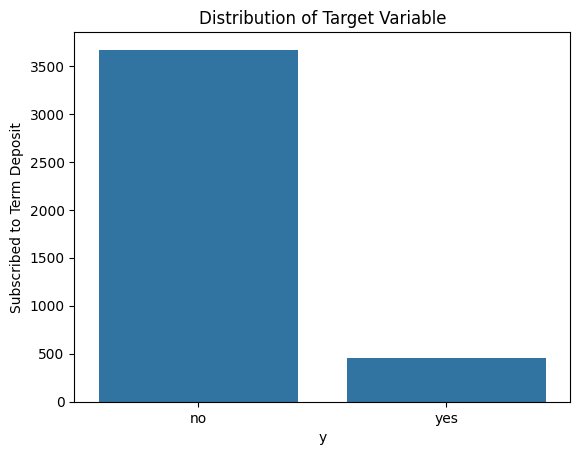

In [49]:
df['y'].value_counts()

sns.countplot(x='y', data=df)
plt.title("Distribution of Target Variable")
plt.ylabel('Subscribed to Term Deposit')
plt.show()

**Detection of Explicit Missing Values:**

In [50]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

**Detection of Implicit Missing Values:**

In [51]:
for col in categorical_features:
    print(col, df[col].value_counts().get("unknown",0))

job 39
marital 11
education 167
default 803
housing 105
loan 105
contact 0
month 0
day_of_week 0
poutcome 0
y 0


**Visualization of Two Numerical Variables (age / campaign):**

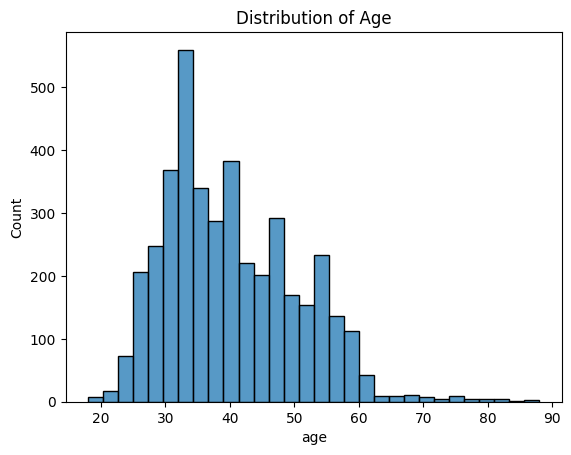

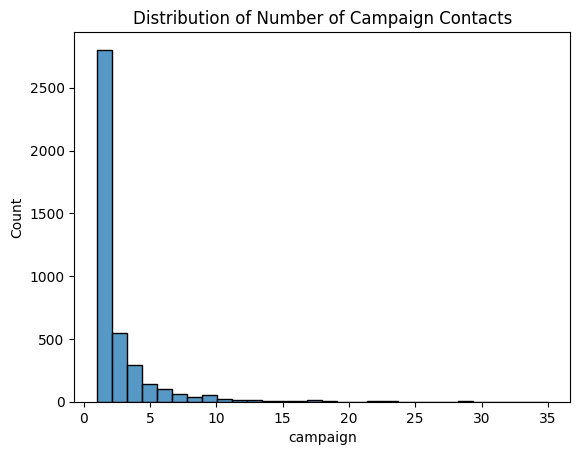

In [52]:
sns.histplot(df['age'], bins=30)
plt.title("Distribution of Age")
plt.show()

sns.histplot(df['campaign'], bins=30)
plt.title("Distribution of Number of Campaign Contacts")
plt.show()

**Visualization of Two Categorical Variables (job / marital):**

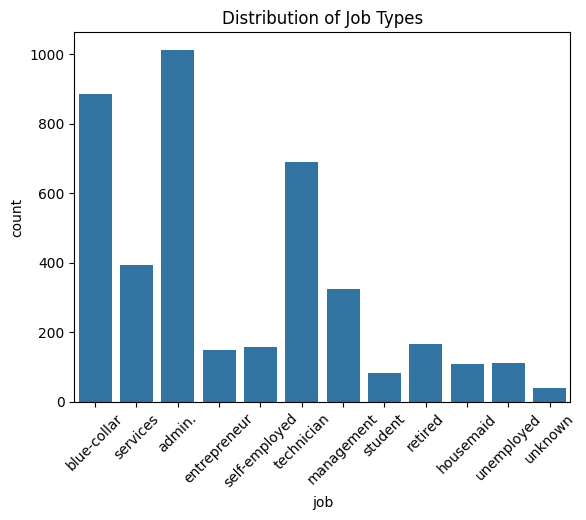

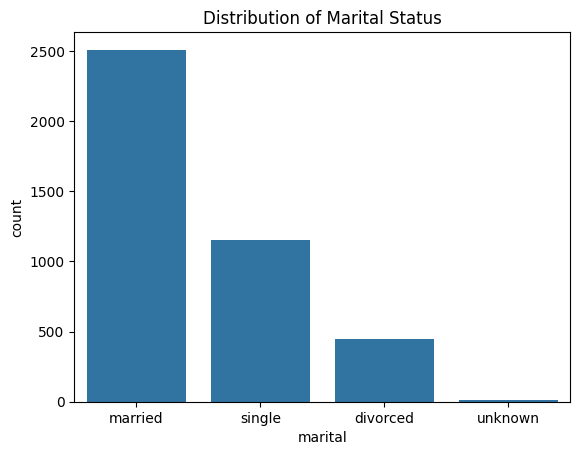

In [53]:
sns.countplot(x='job', data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Job Types")
plt.show()

sns.countplot(x='marital', data=df)
plt.title("Distribution of Marital Status")
plt.show()

### Findings
>*The dataset contains 4,119 observations and 21 variables*
>
>*The numerical features of the dataset are:*
>>'age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'
>
>*The categorical features of the dataset are:*
>>'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y'
>
>*The distribution of the target variable reveals a significant class imbalance, being heavily biased toward no.*
>
>*While no explicit missing values were found, the following implicit missing values categorized as "unknown" were found:*
>>job 39\
>>marital 11\
>>education 167\
>>default 803\
>>housing 105\
>>loan 105\
>>contact 0\
>>month 0\
>>day_of_week 0\
>>poutcome 0\
>>y 0
>
>*The two numerical variables that were visualized are 'age' and 'campaign'. Age is somewhat normally distributed about ~35, and campaign is highly skewed toward lower values. This suggests that 'campaign' may contain outliers or extreme values.*
>
>*The two categorical variables that were visualized are 'job' and 'marital'. The most common job is admin, followed closely by blue-collar and technician. The majority of customers are married beating out single customers by roughly ~50% and divorced customers by a much more significant margin.*
>
>*One variable that may require special consideration due to availability at prediction time is 'duration'. Because duration is only available after the call has ended, it is a metric that is unavailable at prediction time.*

---

## **Task 3 - Data Splitting:**

### **Objective**
>*Split the dataset into training, validation, and test sets while ensuring equitable class distribution.*

### **Methodology**
>*To properly split the dataset, I first made sure to drop the target variable from the dataframe before splitting to avoid data leakage. I then used "train_test_split" from the scikit-learn library to split the new dataframe and target varible into training and temporary sets because the function is only capable of splitting data into two parts at once. I then split the temporary set into the validation and test sets. I used the stratify argument throughout to ensure equitable class distribution between the sets.*

### **Implementation**

In [54]:
from sklearn.model_selection import train_test_split

**Separate the Target Variable from the Dataframe:**

In [55]:
x = df.drop('y', axis=1)
y = df['y']

**Split the Dataset into a Training Set and a Temporary Set:**

In [56]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

**Split the Temporary Set into a Validation Set and a Test Set:**

In [57]:
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

**Check that the Split was Successful:**

In [58]:
print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)

Training set: (2883, 20) (2883,)
Validation set: (618, 20) (618,)
Test set: (618, 20) (618,)


**Check Class Distribution Across Splits:**\
(Stratified Splitting)

In [59]:
print("Full dataset:\n", y.value_counts(normalize=True))
print("\nTraining set:\n", y_train.value_counts(normalize=True))
print("\nValidation set:\n", y_val.value_counts(normalize=True))
print("\nTest set:\n", y_test.value_counts(normalize=True))

Full dataset:
 y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

Training set:
 y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64

Validation set:
 y
no     0.889968
yes    0.110032
Name: proportion, dtype: float64

Test set:
 y
no     0.891586
yes    0.108414
Name: proportion, dtype: float64


### Findings
>*To split the dataset into training, validation, and test sets I used a 70-15-15 split respectively. I chose to allocate the majority of the data to the training set to allow the model to recognize significant patterns, while leaving enough data in the other two sets to allow for reliable performance estimates*
>
>*Stratified splitting was necessary in this case due to the aforementioned class imbalance in the target variable. It was imperative that all three sets reflected this bias toward the "no" class so that any performance estimates against the validation or test sets reflected a realistic class distribution*
>
>*Splitting must occur at the very beginning of the training process, before any feature engineering or modifications take place. This is due to the risk of data leakage. Say for example, we chose to conduct standardization before splitting. The paramaters such as mean and standard deviation that would be learned from the complete dataset, would reflect values that would later be included in the validation and test sets. This means that by transforming the training set with these "corrupted" parameters, we are inadvertently training the model on patterns that are reflected in the validation and test sets. This leads to overfitting and overly optimistic results for a model that generalizes poorly.*
>
>*The same could be said for something like resampling. Say for example a dataset has a class imbalance, much like ours, and we choose to resample before splitting. Although the training set may not suffer too greatly, our model will not generalize well because it was tested against data that is no longer representative of the true distribution.*

---

## **Task 4 - Managing Missing Values:**

### **Objective**
>*Handle explicit and implicit missing values in the dataset.*

### **Methodology**
>*To check for missing values, I used pandas dataframe methods. A search for null values (explicit missing values), was performed using df.isnull(). A further search for implicit missing values was performed by searching for instances of "unknown" in the dataframe. No imputation or removal was performed due to lack of evidence to justify such actions.*

### **Implementation**

**Check for Explicit Missing Values:**

In [60]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

**Check for Implicit Missing Values:**\
("unknown")

In [61]:
for col in categorical_features:
    print(col, (df[col] == "unknown").sum())

job 39
marital 11
education 167
default 803
housing 105
loan 105
contact 0
month 0
day_of_week 0
poutcome 0
y 0


### Findings
>*The dataset contains no explicit missing values. There are however several categories that contain implicit missing values (labeled as "unknown"). Rather than removing these values or altering them using imputation, I decided to retain "unknown" as a valid category. We don't have enough evidence to justify imputation and therefore doing so would require unsupported assumptions. In this specific case, "unknown" represents a lack of information on the part of the bank, which may itself be informative and is treated as such.*

---

## **Task 5 - Encoding Categorical Variables:**

### **Objective**
>*Decide how to encode all categorical variables, and then encode them.*

### **Methodology**
>*To properly encode all categorical variables, I first created an encoder object using scikit-learn's 'OneHotEncoder'. I then fit the encoder to the training set using 'encoder.fit()'. The training set was then encoded using 'encoder.transform()'. Because OneHotEncoder's transform method returns a sparse matrix or Numpy Array (sparse_output=False), I then needed to convert the output back into a Pandas DataFrame. The validation and test sets were then transformed using the encoder that was fit to the training set to avoid data leakage. These sets also subsequently needed to be converted back into DataFrames. Finally, having created a dataset of only encoded categorical variables, I needed to add the numerical variables back to the dataset using the Pandas 'concat' function.*

### **Implementation**

In [62]:
from sklearn.preprocessing import OneHotEncoder

**Identify all Categorical Variables:**

In [63]:
categorical_features = x_train.select_dtypes(include="object").columns
print("Categorical Variables:\n")
for i in (categorical_features):
    print(i)

Categorical Variables:

job
marital
education
default
housing
loan
contact
month
day_of_week
poutcome


**Create Encoder Object:**

In [64]:
encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

**Fit Encoder to the Training Set:**

In [65]:
encoder.fit(x_train[categorical_features])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_c

**Transform the Training Set:**

In [66]:
x_train_encoded = encoder.transform(x_train[categorical_features])
encoded_columns = encoder.get_feature_names_out(categorical_features)
print(encoded_columns)

['job_blue-collar' 'job_entrepreneur' 'job_housemaid' 'job_management'
 'job_retired' 'job_self-employed' 'job_services' 'job_student'
 'job_technician' 'job_unemployed' 'job_unknown' 'marital_married'
 'marital_single' 'marital_unknown' 'education_basic.6y'
 'education_basic.9y' 'education_high.school' 'education_illiterate'
 'education_professional.course' 'education_university.degree'
 'education_unknown' 'default_unknown' 'default_yes' 'housing_unknown'
 'housing_yes' 'loan_unknown' 'loan_yes' 'contact_telephone' 'month_aug'
 'month_dec' 'month_jul' 'month_jun' 'month_mar' 'month_may' 'month_nov'
 'month_oct' 'month_sep' 'day_of_week_mon' 'day_of_week_thu'
 'day_of_week_tue' 'day_of_week_wed' 'poutcome_nonexistent'
 'poutcome_success']


**Convert the Encoded Training Set to a DataFrame:**

In [67]:
x_train_encoded = pd.DataFrame(
    x_train_encoded,
    columns=encoded_columns,
    index=x_train.index
)

x_train_encoded.head()

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
1948,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2198,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
166,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2152,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2881,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


**Transform the Validation and Test Sets:**

In [68]:
x_val_encoded = encoder.transform(x_val[categorical_features])
x_test_encoded = encoder.transform(x_test[categorical_features])

**Convert the Validation and Test Sets to DataFrames:**

In [69]:
x_val_encoded = pd.DataFrame(
    x_val_encoded,
    columns=encoded_columns,
    index=x_val.index
)

x_test_encoded = pd.DataFrame(
    x_test_encoded,
    columns=encoded_columns,
    index=x_test.index
)

**Check Dimensionality after Encoding:**

In [70]:
print(x_train[categorical_features].shape)
print(x_val[categorical_features].shape)
print(x_test[categorical_features].shape)

print(x_train_encoded.shape)
print(x_val_encoded.shape)
print(x_test_encoded.shape)

(2883, 10)
(618, 10)
(618, 10)
(2883, 43)
(618, 43)
(618, 43)


**Identify all Numerical Variables:**

In [71]:
numerical_features = x_train.select_dtypes(exclude="object").columns
print("Numerical Features:\n")
for i in (numerical_features):
    print(i)

Numerical Features:

age
duration
campaign
pdays
previous
emp.var.rate
cons.price.idx
cons.conf.idx
euribor3m
nr.employed


**Add Numerical Variables back to the Encoded Datasets:**

In [72]:
x_train_final = pd.concat([x_train[numerical_features], x_train_encoded], axis=1)
x_val_final = pd.concat([x_val[numerical_features], x_val_encoded], axis=1)
x_test_final = pd.concat([x_test[numerical_features], x_test_encoded], axis=1)

**Check Dimensionality after the Addition of Numerical Variables:**

In [73]:
print(x_train_final.shape)
print(x_val_final.shape)
print(x_test_final.shape)

(2883, 53)
(618, 53)
(618, 53)


### Findings
>*The categorical variables in the dataset are:*
>>'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome'
>
>*All of the categorical variables in the dataset were treated as nominal variables due to a lack of any intrinsic order. While a case could be made for 'education' being an ordinal variable, the lack of a distinct hierarchy in the categories of 'education' led me to treat it as a nominal variable*
>
>*While one could mistake 'month' and 'day_of_week' as ordinal variables, they are in fact nominal due to their circular nature. For example, if I were to use label encoding on months, January would be assigned 1, while December would be assigned 12. Due to this, the model would learn that there is a significant 'difference' between the two, when in reality they are adjacent. Furthermore, any pattern learned based on the month would most likely be seasonal, rendering any monthly hierarchy assigned by label encoding pointless.*
>
>*Because all of the variables are nominal, I chose to use 'OneHotEncoder' across the board. This encoder needed to be fit on the training set only to avoid any data leakage, as well as any confusion due to columns that did not appear in the training set, appearing in the other datasets. This confusion was handled by the 'handle_unknown' parameter in the creation of the 'OneHotEncoder' instance*
>
>*Originally the dataset contained 10 categorical variables. After encoding, the dimensionality of the categorical dataset increased significantly, going from 10 columns to 43. After the addition of the numerical variables, the overall dimensionality of the dataset increased from 20 columns to 53*
>
>*My choice to use one-hot encoding allows the model to assign independent coefficients to each type of job, allowing it to discern and attribute independent effects on the decision boundary to each job. If I had used label encoding, the model would be forced to attribute some type of hierarchy and numerical value to each job. For example, it would learn that the effect that 'admin' has on the decision boundary is three times that of 'technician', which doesn't make any sense and would confuse the model as it tried to fit a line to these senseless values.*

---

## **Task 6 - Feature Selection:**

### **Objective**
>*Decide which features, if any, need to be removed.*

### **Methodology**
>*To decide if any features needed to be removed, I started by conducting a test to check if any features had low variance. I used the Numpy '.var()' and Pandas '.sort_values()' methods to create a variance table. I then used the Pandas '.corr()' method to check for high correlation among the numerical features. Finally, 'duration' was removed using '.drop()' due to 'duration' not being available at prediction time.*

### **Implementation**

In [74]:
import numpy as np

**Check for Low Variance:**

In [75]:
x_train[numerical_features].var().sort_values()

previous              0.314198
cons.price.idx        0.342768
emp.var.rate          2.446584
euribor3m             3.014293
campaign              6.868147
cons.conf.idx        21.430475
age                 107.446945
nr.employed        5481.697956
pdays             39049.991305
duration          67961.688316
dtype: float64

**Check for High Correlation:**

In [76]:
corr_matrix = x_train[numerical_features].corr()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = upper_triangle.stack().reset_index()
high_corr.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr = high_corr[high_corr["Correlation"].abs() > 0.8]

print(high_corr)

       Feature 1    Feature 2  Correlation
37  emp.var.rate    euribor3m     0.969648
38  emp.var.rate  nr.employed     0.895815
44     euribor3m  nr.employed     0.942087


**Correlation Matrix of Numerical Features:**

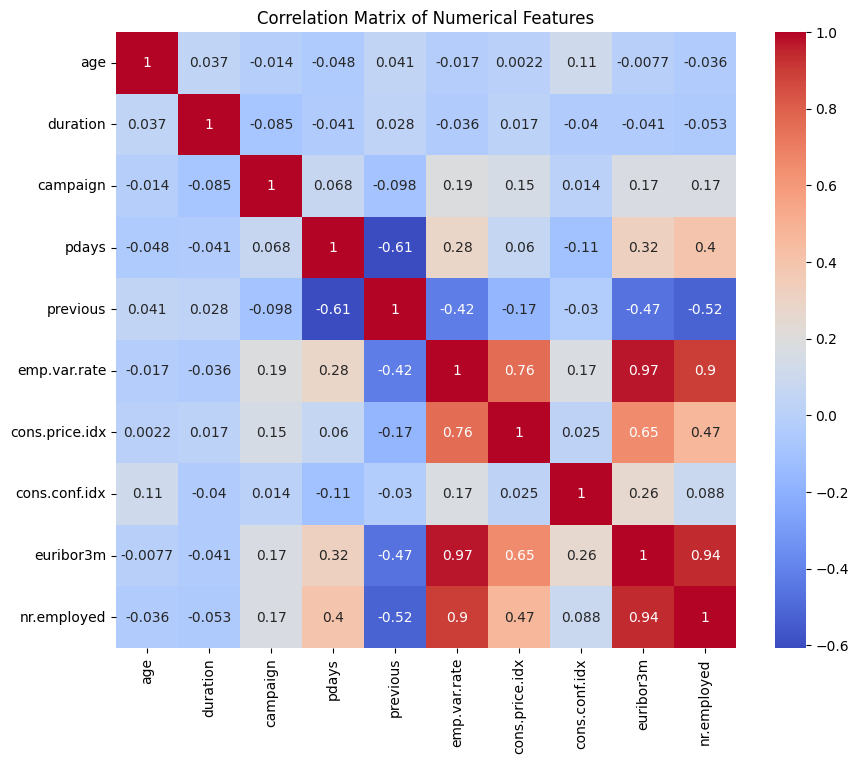

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

**Remove 'duration':**

In [78]:
x_train_final = x_train_final.drop(columns=["duration"])
x_val_final = x_val_final.drop(columns=["duration"])
x_test_final = x_test_final.drop(columns=["duration"])

**Check that 'duration' was Properly Removed:**

In [79]:
print(x_train_final.shape)
print(x_val_final.shape)
print(x_test_final.shape)

(2883, 52)
(618, 52)
(618, 52)


### Findings
>*Although 'previous' and 'cons.price.idx' had variances of ~0.3, based on a threshold of 0.1, no features exhibited near-zero variance. Accordingly, all variables showed sufficient variability to contribute meaningful information.*
>
>*My tests of correlation revealed the following:*
>>emp.var.rate -- euribor3m -- 0.969648\
>>emp.var.rate -- nr.employed -- 0.895815\
>>euribor3m -- nr.employed -- 0.942087\
>
>*Although I decided on a threshold of 0.8, I decided to retain the correlated variables because they indicate different aspects of the economic environment at prediction time.*
>
>*I removed 'duration' due to data leakage. At prediction time, 'duration' is not available.*
>
>*Feature selection must be performed using only the training set, because if values such as variance and correlation are calculated using the full dataset, decisions may be made based on patterns that manifest in the validation and test sets, leading to overly optimistic results and poor generalization. It is for this same reason that feature selection cannot be performed before splitting the data as decisions could be made that are based on patterns that are only apparent when including the validation and test data.*

---

## **Task 7 - Feature Scaling:**

### **Objective**
>*Ensure that all numerical features are properly scaled*

### **Methodology**
>*To ensure that all variables are scaled properly, I first checked the scale of each of the numerical variables using Pandas '.agg()' to create a table. Then, using scikit-learn's 'StandardScaler', I created a scaler object and fit it to the training set. The parameters learned from the training set were then used to transform the training, validation, and test sets. Finally, I used '.agg()' again to check that the scaling was executed correctly.*

### **Implementation**

In [81]:
from sklearn.preprocessing import StandardScaler

**Check the Scale of all Numerical Variables:**

In [80]:
numerical_features = numerical_features.drop("duration")

scale_summary = x_train_final[numerical_features].agg(
    ["min", "max", "mean", "std"]
).T

scale_summary

,min,max,mean,std
age,18.000,86.000,40.197017,10.365662
campaign,1.000,35.000,2.548387,2.620715
pdays,0.000,999.000,958.004509,197.610706
previous,0.000,6.000,0.200139,0.560534
emp.var.rate,-3.400,1.400,0.073500,1.564156
cons.price.idx,92.201,94.767,93.580633,0.585464
cons.conf.idx,-50.800,-26.900,-40.438259,4.629306
euribor3m,0.635,5.045,3.612443,1.736172
nr.employed,4963.600,5228.100,5165.766424,74.038490


**Create a Scaler Object and Fit it to the Training Set:**

In [82]:
scaler = StandardScaler()
scaler.fit(x_train_final[numerical_features])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


**Transform all Datasets using Parameters Learned from the Training Set:**

In [83]:
x_train_final[numerical_features] = scaler.transform(x_train_final[numerical_features])
x_val_final[numerical_features] = scaler.transform(x_val_final[numerical_features])
x_test_final[numerical_features] = scaler.transform(x_test_final[numerical_features])

**Check that all Numerical Variables were Scaled Correctly:**

In [84]:
x_train_final[numerical_features].agg(["mean", "std"]).T

,mean,std
age,-4.929190e-18,1.000173
campaign,-7.393785e-18,1.000173
pdays,-1.370931e-16,1.000173
previous,1.016645e-17,1.000173
emp.var.rate,-4.682730e-17,1.000173
cons.price.idx,-2.980928e-15,1.000173
cons.conf.idx,6.629761e-16,1.000173
euribor3m,-4.436271e-17,1.000173
nr.employed,1.025456e-14,1.000173


### Findings
>*The numerical variables that needed to be scaled are:*
>>'age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'
>
>*The scaling strategy I chose was standardization with parameters mean and standard deviation fit to the training set only. If I would have fit the parameters on the entire dataset it would have led to data leakage, because values included in the validation and test set would have also been reflected in the learned parameters.*
>
>*My choice to use standardization was motivated by the fact that, in logistic regression, gradient descent performs best using a dataset with standardized features. This is because scaled features improve the symmetry of the loss function, allowing the gradient descent to move more efficiently. Furthermore, in the gradient descent equation, the scale of each feature has a direct impact on the step size. Therefore, with the scale of each feature standardized, gradient descent converges faster and more reliably.*
>
>*Scaling also affects the magnitude of model coefficients. For example, if features are not scaled, a hypothetical feature such as 'salary' would have a much larger value than a feature such as 'age', meaning that 'salary' would be assigned a much smaller coefficient. Not because it has a smaller effect, but simply because it has a larger value. For this same reason, non-scaled features are penalized by regularization unevenly because some larger features have far smaller coefficients than others. Scaling fixes this by standardizing all feature values to a similar size, making coefficient sizes more consistent and able to more accurately reflect the true influence of each variable.*

---

## **Task 8 - Addressing Class Imbalance:**

### **Objective**
>*Address any class imbalance in the training set.*

### **Methodology**
>*To address class imbalance in the training set, I first used Pandas '.value_counts()' to check for class imbalance in the target variable. I then used imbalanced-learn's 'SMOTE' to create an instance of a SMOTE object, and then fit it to my training set. Finally, I once again used '.value_counts()' to ensure that the resampling was properly applied to the training set.*

### **Implementation**

In [88]:
from imblearn.over_sampling import SMOTE

**Check for Imbalance:**

In [87]:
y_train.value_counts(normalize=True)

y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64

**Create SMOTE Instance:**

In [89]:
smote = SMOTE(random_state=42)

**Use SMOTE to Resample the Training Set:**

In [90]:
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_final, y_train)

**Check that the Resampling fixed the Imbalance:**

In [91]:
y_train_resampled.value_counts(normalize=True)

y
no     0.5
yes    0.5
Name: proportion, dtype: float64

### Findings
>*The class imbalance in the training set was:*
>>y\
>>no     0.890392\
>>yes    0.109608
>
>*This is a significant class imbalance which could lead to overly optimistic model accuracy. If I were to leave the class imbalance as is, a model could learn to simply predict the majority class. This would lead to a "lazy" model with high accuracy but very poor precision.*
>
>*The resampling strategy I decided on was SMOTE. At first I was going to use normal Oversampling, however I decided against it due to risk of overfitting.*
>
>*Resampling should occur as the final step before model training to ensure that the resample reflects any past changes such as scaling and feature selection. If resampling were to be applied before splitting the original dataset, it would lead to massive data leakage. Any values learned and used by the resampling would be heavily influenced by both the validation and test data, which would lead to extreme overfitting and overly optimistic performance results.*
>
>*It is also important to be cognizant of the fact that resampling must only be performed on the training set. It is imperative that the validation and test sets maintain a realistic class distribution.*
>
>*Furthermore, class imbalance has a significant effect on evaluation metrics. In an imbalanced training set, we can expect to see high accuracy, but poor precision and recall. This is because in an imbalanced dataset, a model may learn to simply predict the majority class. For example, if the majority 'no' class is 90%, the model can simply guess 'no' 90% of the time. This would result in an accuracy of ~90%, however, this also leads to the model performing poorly at identifying the minority class, leading to very poor recall. While precision may not be too heavily affected, it may also decrease depending on the number of false positives.*

---

## **Task 9 - Training a Logistic Regression Model:**

### **Objective**
>*Train a logistic regression model using the data pipeline that was created throughout the project.*

### **Methodology**
>*To start, I decided to first try training a logistic regression straight off of the processed training set without any hyperparameter tuning using scikit-learn's 'LogisticRegression'. Next, after testing it against the validation set using '.predict()', I tried multiple different C values, as well as different decision threshold values (using '.predict_proba()') to find the optimal hyperparameters. Finally, I trained the final model using the hyperparameters I found, and tested the final model against the test set.*

### **Implementation**

In [155]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

**Test Base Model Training without Tuning:**

In [156]:
base_model = LogisticRegression(max_iter=1000, C=0.1)
base_model.fit(x_train_resampled, y_train_resampled)

base_y_val_pred = base_model.predict(x_val_final) 

accuracy = accuracy_score(y_val, base_y_val_pred)
precision = precision_score(y_val, base_y_val_pred, pos_label="yes")
recall = recall_score(y_val, base_y_val_pred, pos_label="yes")

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

Accuracy: 0.8317152103559871
Precision: 0.35714285714285715
Recall: 0.6617647058823529


**Test Model with Different C Values:**

In [157]:
C_values = [0.01, 0.1, 1, 10]

results = []

for C in C_values:
    test_model = LogisticRegression(
        C=C,
        max_iter=1000
    )

    test_model.fit(x_train_resampled, y_train_resampled)

    y_val_pred_test = test_model.predict(x_val_final)

    accuracy = accuracy_score(y_val, y_val_pred_test)
    precision = precision_score(y_val, y_val_pred_test, pos_label="yes")
    recall = recall_score(y_val, y_val_pred_test, pos_label="yes")

    results.append({
        "C": C,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall
    })

c_results = pd.DataFrame(results)
c_results

,C,accuracy,precision,recall
0,0.01,0.809061,0.323944,0.676471
1,0.10,0.831715,0.357143,0.661765
2,1.00,0.828479,0.351562,0.661765
3,10.00,0.830097,0.352000,0.647059


**Test Model with Different Thresholds:**

In [158]:
test_model = LogisticRegression(max_iter=1000, C=0.1)
test_model.fit(x_train_resampled, y_train_resampled)

y_val_probs_test = test_model.predict_proba(x_val_final)[:, 1]
thresholds = [0.50, 0.55, 0.60, 0.65, 0.70]

results = []

for threshold in thresholds:
    y_val_pred_thresh = np.where(y_val_probs_test >= threshold, "yes", "no")

    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, y_val_pred_thresh),
        "precision": precision_score(y_val, y_val_pred_thresh, pos_label="yes"),
        "recall": recall_score(y_val, y_val_pred_thresh, pos_label="yes")
    })

threshold_results = pd.DataFrame(results)
threshold_results

,threshold,accuracy,precision,recall
0,0.50,0.831715,0.357143,0.661765
1,0.55,0.867314,0.431373,0.647059
2,0.60,0.885113,0.482759,0.617647
3,0.65,0.889968,0.500000,0.573529
4,0.70,0.891586,0.507246,0.514706


**Train Final Model with Optimal Hyperparameters:**

In [159]:
final_model = LogisticRegression(max_iter=1000, C=0.1)
final_model.fit(x_train_resampled, y_train_resampled)

threshold = 0.6
y_val_probs = final_model.predict_proba(x_val_final)[:, 1]
y_val_pred_final = np.where(y_val_probs >= threshold, "yes", "no")

accuracy = accuracy_score(y_val, y_val_pred_final)
precision = precision_score(y_val, y_val_pred_final, pos_label="yes")
recall = recall_score(y_val, y_val_pred_final, pos_label="yes")

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

Accuracy: 0.8851132686084142
Precision: 0.4827586206896552
Recall: 0.6176470588235294


**Confusion Matrix of the Final Model (Validation Set):**

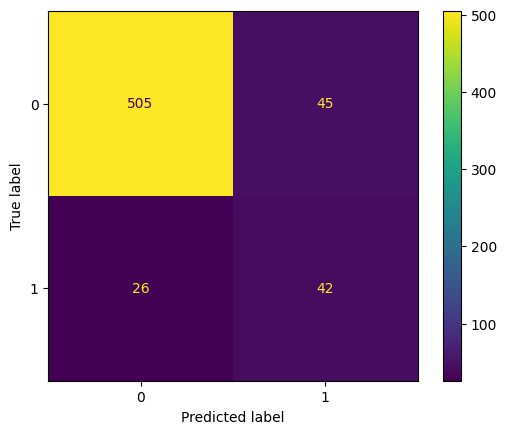

In [160]:
cm = confusion_matrix(y_val, y_val_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

**Test the Final Model against the Test Set:**

In [161]:
threshold = 0.6

y_test_probs = final_model.predict_proba(x_test_final)[:, 1]
y_test_pred = np.where(y_test_probs >= threshold, "yes", "no")

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, pos_label="yes")
recall = recall_score(y_test, y_test_pred, pos_label="yes")

print(f"Test Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")

Test Accuracy: 0.8511326860841424
Test Precision: 0.3563218390804598
Test Recall: 0.4626865671641791


**Confusion Matrix of the Final Model (Test Set):**

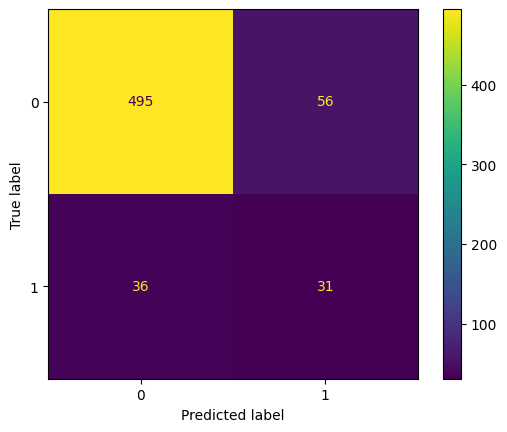

In [162]:
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

**Zero Rule Baseline:**

Baseline Accuracy: 0.889967637540453


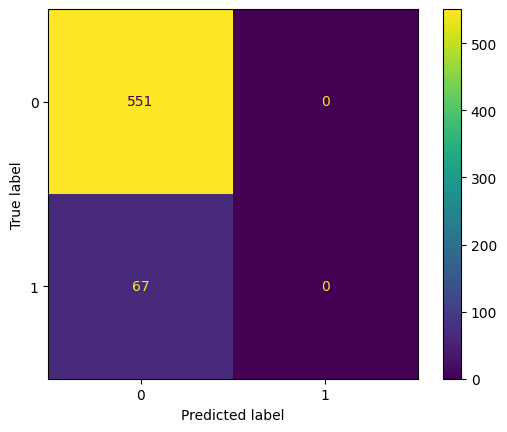

In [166]:
zero_rule = y_val.value_counts(normalize=True).max()
print(f"Baseline Accuracy: {zero_rule}")
cm = confusion_matrix(y_test, ["no"] * len(y_test))
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

### Findings
>*The base performance of the model without tuning was:*
>>Accuracy: 0.8317152103559871\
>>Precision: 0.35714285714285715\
>>Recall: 0.6617647058823529
>
>*The results of experimenting with the C value were:*
>>|     C |   accuracy |   precision |   recall |
>>|------:|-----------:|------------:|---------:|
>>|  0.01 |   0.809061 |    0.323944 | 0.676471 |
>>|  0.1  |   0.831715 |    0.357143 | 0.661765 |
>>|  1    |   0.828479 |    0.351562 | 0.661765 |
>>| 10    |   0.830097 |    0.352    | 0.647059 |
>
>*The results of experimenting with the decision threshold were:*
>>|   threshold |   accuracy |   precision |   recall |
>>|------------:|-----------:|------------:|---------:|
>>|        0.5  |   0.831715 |    0.357143 | 0.661765 |
>>|        0.55 |   0.867314 |    0.431373 | 0.647059 |
>>|        0.6  |   0.885113 |    0.482759 | 0.617647 |
>>|        0.65 |   0.889968 |    0.5      | 0.573529 |
>>|        0.7  |   0.891586 |    0.507246 | 0.514706 |
>
>*In the end I decided:*
>>C = 0.1\
>>Decision Threshold = 0.6.
>
>*Using these hyperparameters produced the following results when tested against the validation set:*
>>Accuracy: 0.8851132686084142\
>>Precision: 0.4827586206896552\
>>Recall: 0.6176470588235294
>>
>>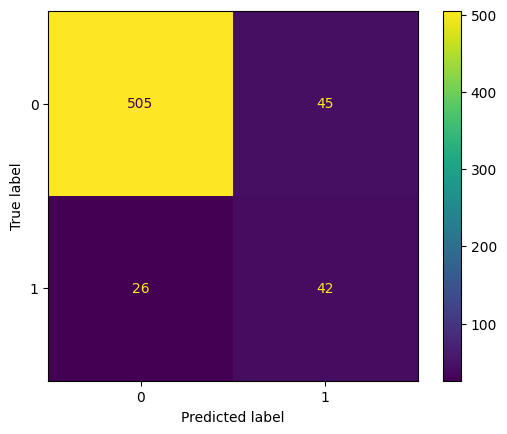
>
>*Finally, testing against the test set yielded the following results:*
>>Test Accuracy: 0.8511326860841424\
>>Test Precision: 0.3563218390804598\
>>Test Recall: 0.4626865671641791
>>
>>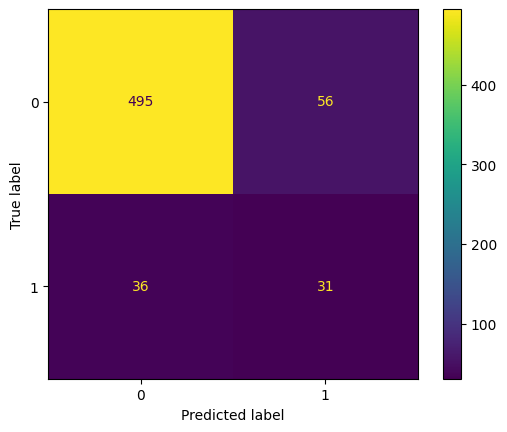
>
>*Although accuracy is slightly lower, precision and recall are significantly improved when compared to the zero rule baseline:*
>>Baseline Accuracy: 0.889967637540453\
>>Baseline Precision: 0\
>>Baseline Recall: 0
>>
>>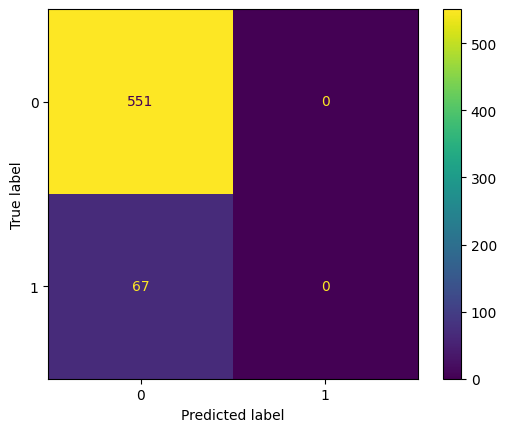
>
>*This demonstrates that the model is able to identify potential subscribers as opposed to only predicting the majority class.*
>
>*In retrospect, a lower threshold may have been more appropriate in this context in order to better prioritize recall. The consequence of lower precision is less important than that of lower recall in this context, as lower recall means lost business. However, seeing as I selected the threshold using validation performance, the threshold was not altered after observing the results of testing against the test set.*

---